# Nonparametric tail copula density estimation

This notebook demonstrates [`npptcop`](../src/npptcop), the *second step* of the pieced-together copula density method: a nonparametric estimator of the copula density in a tail corner.

We simulate a Clayton copula (which has lower-left tail dependence), fit the lower-left tail estimator, and compare the estimated copula density `c`, tail copula density `r`, and tail-conditional density `h` against the truth. We then show how the `rotation` parameter handles all four corners.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pyvinecopulib as pv
from matplotlib.colors import LogNorm

from npptcop import TailCopula, grid_metrics_density, unit_grid

torch.set_default_dtype(torch.float64)

## Simulate data

A Clayton copula with parameter $\theta = 3$ and the tail cutoff $q = n^{-1/2}$.

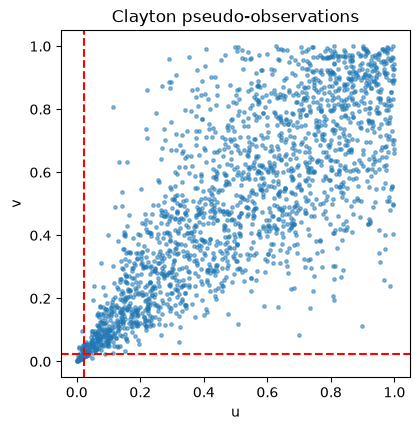

In [2]:
n = 2000
theta = 3.0
q = n ** (-0.5)

bicop = pv.Bicop(
  family=pv.BicopFamily.clayton,
  parameters=np.array([[theta]], dtype=float),
)
u = torch.as_tensor(bicop.simulate(n, seeds=[97]), dtype=torch.float64)

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(u[:, 0], u[:, 1], s=6, alpha=0.5)
ax.axvline(q, color="r", ls="--")
ax.axhline(q, color="r", ls="--")
ax.set(xlabel="u", ylabel="v", title="Clayton pseudo-observations")
plt.show()

## Fit the lower-left tail estimator

`TailCopula` extracts the observations in the corner block $[0, q]^2$, rescales them to $[0, 1]^2$, and fits a probit-transform local-likelihood KDE. The fitted summary exposes the tail mass $p = k/n$ and the tail count $k$.

In [3]:
est = TailCopula(q, rotation=0).fit(u)
fit = est.fit_
print(f"tail count k = {fit.k}")
print(f"tail mass  p = {fit.p:.4f}")
print(f"bandwidth:\n{fit.bandwidth}")

tail count k = 33
tail mass  p = 0.0165
bandwidth:
tensor([[0.3037, 0.2056],
        [0.2056, 0.3037]])


## Compare to the true copula density

Evaluate the targets on a grid of rescaled coordinates $s \in [0, 1]^2$ and compare the estimated copula density `c` to the analytic Clayton density on the corner block via integrated error metrics.

In [4]:
grid, cell_area = unit_grid(size=60)
cell_area_tail = (q**2) * cell_area

h = est.h(grid)  # tail-conditional density on [0, 1]^2
c = est.c(grid)  # copula density at (q * s)
r = est.r(grid)  # tail copula density (lambda)

c_true = torch.as_tensor(bicop.pdf((grid * q).numpy()), dtype=torch.float64)
metrics = grid_metrics_density(c, c_true, cell_area_tail)
print({k: round(v, 4) for k, v in metrics.items()})

{'ISE': 17977.6198, 'IAE': 0.0582, 'KL': 0.299}


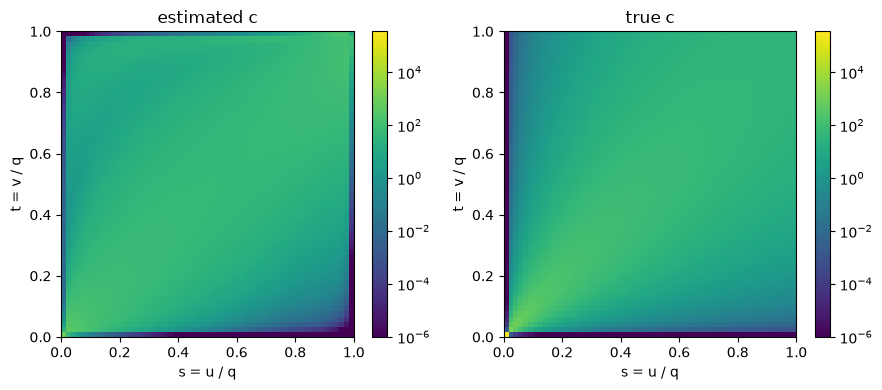

In [5]:
m = 60
extent = [0.0, 1.0, 0.0, 1.0]
c_hat_grid = c.reshape(m, m).T.numpy()
c_true_grid = c_true.reshape(m, m).T.numpy()
norm = LogNorm(
  vmin=min(c_hat_grid.min(), c_true_grid.min()) + 1e-6,
  vmax=max(c_hat_grid.max(), c_true_grid.max()),
)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
panels = ((c_hat_grid, "estimated c"), (c_true_grid, "true c"))
for ax, (data, title) in zip(axes, panels):
  im = ax.imshow(data, origin="lower", extent=extent, norm=norm, aspect="auto")
  ax.set(xlabel="s = u / q", ylabel="t = v / q", title=title)
  fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## All four corners via rotation

`rotation` selects the corner (0 lower-left, 90 lower-right, 180 upper-right, 270 upper-left), matching pyvinecopulib's density-rotation convention. Feeding data from a rotated Clayton populates the corresponding corner.

In [6]:
for rotation in (0, 90, 180, 270):
  truth = pv.Bicop(
    family=pv.BicopFamily.clayton,
    rotation=rotation,
    parameters=np.array([[theta]], dtype=float),
  )
  ur = torch.as_tensor(truth.simulate(n, seeds=[97]), dtype=torch.float64)
  est_r = TailCopula(q, rotation=rotation).fit(ur)
  print(f"rotation={rotation:3d}: tail count k = {est_r.fit_.k}")

rotation=  0: tail count k = 33
rotation= 90: tail count k = 43
rotation=180: tail count k = 36
rotation=270: tail count k = 35
